In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("ahmedelsany/car-brand-classification-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'car-brand-classification-dataset' dataset.
Path to dataset files: /kaggle/input/car-brand-classification-dataset
Contents of base_path (/kaggle/input):
['car-brand-classification-dataset']
Contents of path (/kaggle/input/car-brand-classification-dataset):
['Car Brand Classification Dataset']


In [ ]:
print(f"Contents of the 'train' directory: {os.listdir(os.path.join(path, 'Car Brand Classification Dataset', 'train'))}")
print(f"Contents of the 'test' directory: {os.listdir(os.path.join(path, 'Car Brand Classification Dataset', 'test'))}")

Contents of the 'train' directory: ['Nissan', 'Ford', 'Hyundai', 'Mercedes-Benz', 'Chrysler', 'GMC', 'Lincoln', 'FIAT', 'Aston Martin', 'Volkswagen', 'Land Rover', 'Buick', 'Honda', 'Dodge', 'Porsche', 'Kia', 'Toyota', 'Jeep', 'Volvo', 'Mitsubishi', 'Cadillac', 'Chevrolet', 'Jaguar', 'Bentley', 'BMW', 'Lexus', 'Audi', 'INFINITI', 'Acura', 'Subaru', 'Mazda', 'Ram', 'MINI']
Contents of the 'test' directory: ['Nissan', 'Ford', 'Hyundai', 'Mercedes-Benz', 'Chrysler', 'GMC', 'Lincoln', 'FIAT', 'Aston Martin', 'Volkswagen', 'Land Rover', 'Buick', 'Honda', 'Dodge', 'Porsche', 'Kia', 'Toyota', 'Jeep', 'Volvo', 'Mitsubishi', 'Cadillac', 'Chevrolet', 'Jaguar', 'Bentley', 'BMW', 'Lexus', 'Audi', 'INFINITI', 'Acura', 'Subaru', 'Mazda', 'Ram', 'MINI']



--- Sample Images from Training Dataset (/kaggle/input/car-brand-classification-dataset/Car Brand Classification Dataset/train) ---
Found 11517 images in /kaggle/input/car-brand-classification-dataset/Car Brand Classification Dataset/train. Displaying 6 samples:


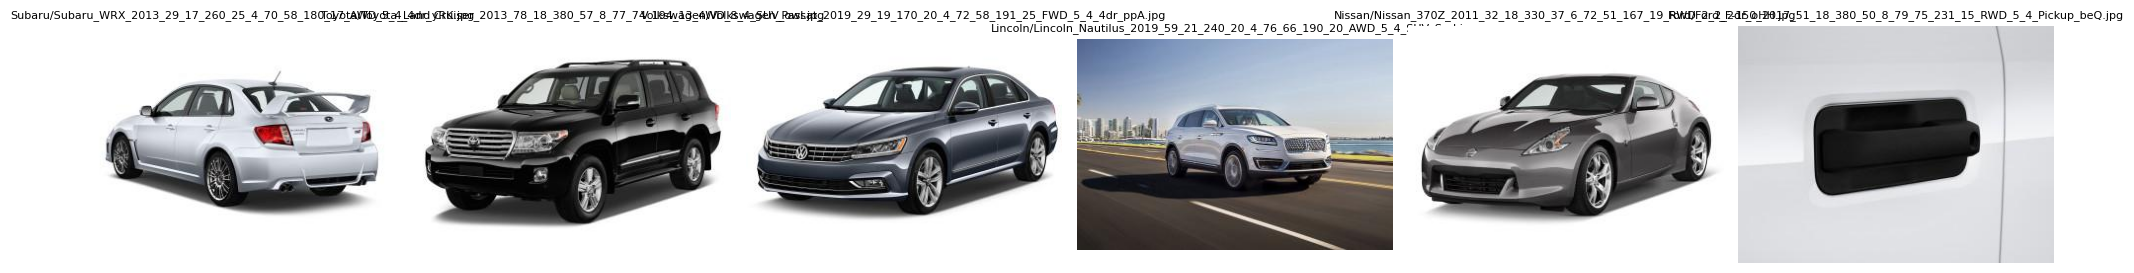


--- Sample Images from Test Dataset (/kaggle/input/car-brand-classification-dataset/Car Brand Classification Dataset/test) ---
Found 2475 images in /kaggle/input/car-brand-classification-dataset/Car Brand Classification Dataset/test. Displaying 6 samples:


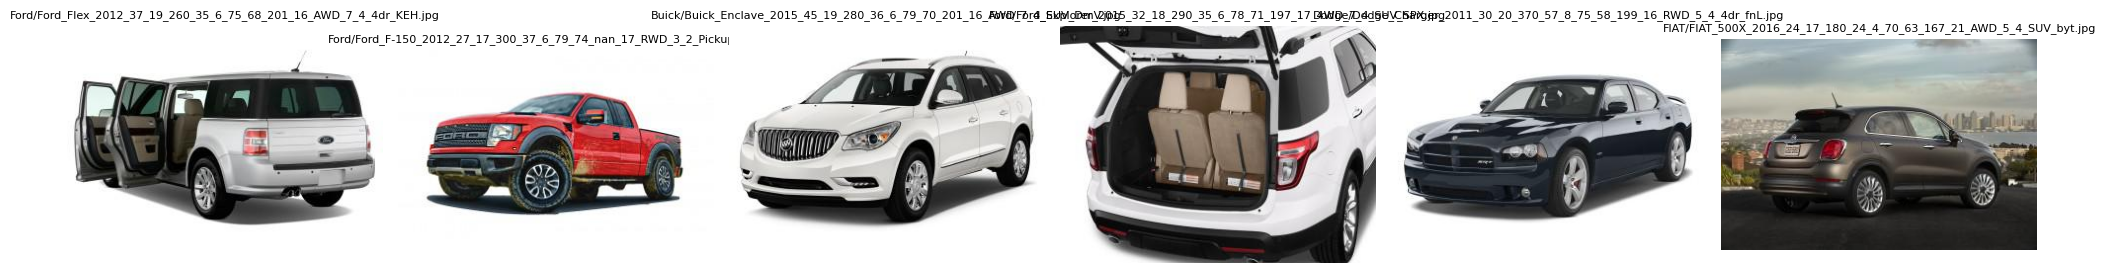

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images in {dataset_path}. Displaying {min(num_samples, len(all_image_paths))} samples:")

    # Select random samples to display
    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]
    elif len(samples_to_display) == 0:
        plt.close(fig)
        return

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(os.path.basename(os.path.dirname(img_path)) + '/' + os.path.basename(img_path), fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Updated paths to include 'Car Brand Classification Dataset' subdirectory
train_path = os.path.join(path, 'Car Brand Classification Dataset', 'train')
print(f"\n--- Sample Images from Training Dataset ({train_path}) ---")
display_sample_images(train_path)

test_path = os.path.join(path, 'Car Brand Classification Dataset', 'test')
print(f"\n--- Sample Images from Test Dataset ({test_path}) ---")
display_sample_images(test_path)

In [ ]:
import tensorflow as tf

# Check if GPU is available
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
if tf.test.gpu_device_name():
    print('Default GPU Device: {}'.format(tf.test.gpu_device_name()))
else:
    print("Please install GPU version of TF or check your Colab Runtime settings (Runtime > Change runtime type).")

Num GPUs Available:  1
Default GPU Device: /device:GPU:0


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers

# Set parameters
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Data Augmentation and Loading
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Building a VGG-style Model
def build_vgg_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2), strides=(2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2), strides=(2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

num_classes = len(train_generator.class_indices)
model = build_vgg_model(IMG_SIZE + (3,), num_classes)

model.compile(optimizer=optimizers.Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# Train the model
print("\nStarting Training...")
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

Found 11517 images belonging to 33 classes.
Found 2475 images belonging to 33 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    33,554,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 33)             │         8,481 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,823,329 (129.03 MB)

 Trainable params: 33,823,329 (129.03 MB)

 Non-trainable params: 0 (0.00 B)


Starting Training...
Epoch 1/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 131s 322ms/step - accuracy: 0.0324 - loss: 3.4982 - val_accuracy: 0.0400 - val_loss: 3.4938
Epoch 2/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 73s 202ms/step - accuracy: 0.0359 - loss: 3.4920 - val_accuracy: 0.0457 - val_loss: 3.4831
Epoch 3/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 73s 202ms/step - accuracy: 0.0424 - loss: 3.4794 - val_accuracy: 0.0610 - val_loss: 3.4511
Epoch 4/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 72s 199ms/step - accuracy: 0.0523 - loss: 3.4647 - val_accuracy: 0.0756 - val_loss: 3.4283
Epoch 5/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 72s 199ms/step - accuracy: 0.0593 - loss: 3.4446 - val_accuracy: 0.0675 - val_loss: 3.4261
Epoch 6/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 73s 203ms/step - accuracy: 0.0608 - loss: 3.4364 - val_accuracy: 0.0760 - val_loss: 3.3993
Epoch 7/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 72s 201ms/step - accuracy: 0.0688 - loss: 3.4158 - val_accuracy: 0.0877 - val_loss: 3.3660
Epoch 8/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 70s 194ms/step - acc

In [ ]:
import numpy as agricultural
from sklearn.metrics import classification_report, confusion_matrix

# Evaluate the model
loss, accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {accuracy*100:.2f}%")

# Get predictions
Y_pred = model.predict(test_generator)
y_pred = agricultural.argmax(Y_pred, axis=1)

print('\nClassification Report')
target_names = list(train_generator.class_indices.keys())
print(classification_report(test_generator.classes, y_pred, target_names=target_names))

78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.0954 - loss: 3.3389
Test Accuracy: 9.54%
78/78 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step

Classification Report
               precision    recall  f1-score   support

        Acura       0.09      0.03      0.04        75
 Aston Martin       0.11      0.19      0.14        75
         Audi       1.00      0.01      0.03        75
          BMW       0.11      0.01      0.02        75
      Bentley       0.10      0.23      0.13        75
        Buick       0.05      0.04      0.05        75
     Cadillac       0.00      0.00      0.00        75
    Chevrolet       0.01      0.01      0.01        75
     Chrysler       0.08      0.05      0.06        75
        Dodge       0.16      0.04      0.06        75
         FIAT       0.15      0.09      0.11        75
         Ford       0.17      0.05      0.08        75
          GMC       0.11      0.32      0.17        75
        Honda       0.08      0.03      0.04        75
      Hyundai   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


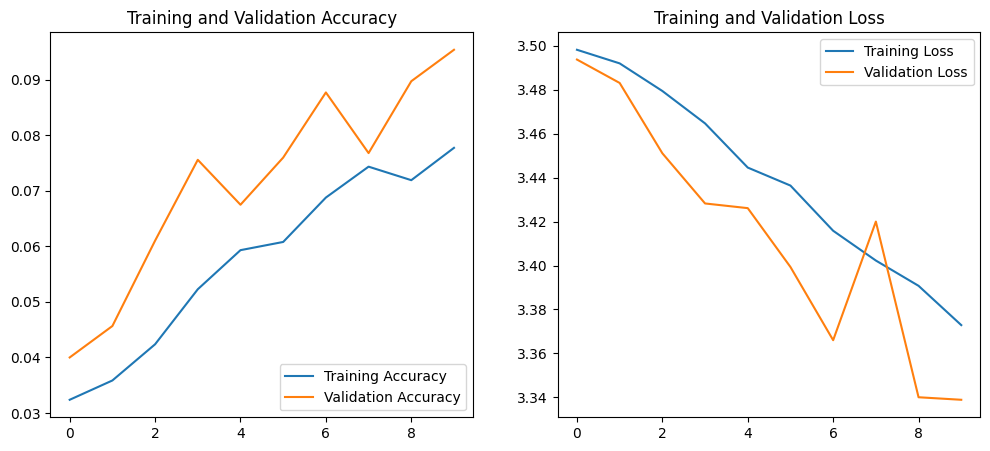

In [ ]:
import matplotlib.pyplot as plt

# Plot Training History
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend(loc='lower right')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend(loc='upper right')

    plt.show()

plot_history(history)